In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils import data
from torch import nn, optim
from torch.nn import Transformer
from random import random
from tqdm import tqdm
import torch.nn.functional as F
import math
from collections import OrderedDict
import pandas as pd
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# 定义变量路径
CHANGE_DATA_PATH = r"H:\7.Eco_parameter\Hunan_LULC\Sample\change.npy"
STABLE_DATA_PATH = r"H:\7.Eco_parameter\Hunan_LULC\Sample\balanced_stable.npy"

BATCH_SIZE = 1024
EPOCH = 500
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
# 计算 平均值和标准差 ，便于归一化
stable_data = np.load(STABLE_DATA_PATH, allow_pickle=True)
change_data = np.load(CHANGE_DATA_PATH, allow_pickle=True)
data0 = np.concatenate((stable_data, change_data), axis=0)
# 提取要计算均值和标准差的波段
bands_data = data0[:, :6, :]
# 确保数据为数值类型
bands_data = bands_data.astype(np.float32)
bands_data = bands_data

# 计算每个波段的均值和标准差
mean = np.mean(bands_data, axis=(0, 2))
std = np.std(bands_data, axis=(0, 2))

print("均值:", mean)
print("标准差:", std)

均值: [ 914.1453 1094.7517 1133.948  2160.0928 1953.543  1468.8158]
标准差: [ 569.4535   656.3193   901.48566 1176.8358  1303.2179  1239.0968 ]


In [4]:
data0.shape

(43610, 7, 34)

In [5]:
data_segment = data0[:, 6:, :]

# 将数据展平为一维数组
flattened_data = data_segment.flatten()

# 使用 numpy 的 unique 函数统计不同值的出现次数
unique_values, counts = np.unique(flattened_data, return_counts=True)

# 打印结果
for value, count in zip(unique_values, counts):
    print(f"值 {value} 出现次数: {count}")

值 0 出现次数: 280751
值 1.0 出现次数: 294254
值 2.0 出现次数: 193090
值 3.0 出现次数: 154844
值 4.0 出现次数: 320828
值 5.0 出现次数: 238973


In [6]:
class MaskDataset(data.Dataset):
    def __init__(self, dataset, model_type):
        super(MaskDataset, self).__init__()
        self.dataset = dataset
        self.model_type = model_type   # 如果为train则实施数据增强

    def __getitem__(self, index):
        data, label = self.dataset[index, :-1], self.dataset[index, -1]
                
        # 标准化   
        MEAN = mean
        STD = std
        data = (data - MEAN[:, None]) / STD[:, None]
        
        # 确保返回的是 numpy 数组或 torch 张量
        data = data.astype(np.float32)
        label = label.astype(np.float32)

        return torch.tensor(data, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

    def __len__(self):
        return self.dataset.shape[0]    # 返回数据集的大小

def load_data(batch_size):
    # 加载数据
    change_sample = np.load(CHANGE_DATA_PATH, allow_pickle=True)[:, :7]    # 6个波段 + 1个标签 维度
    stable_sample = np.load(STABLE_DATA_PATH, allow_pickle=True)[:, :7]
    np.random.shuffle(change_sample)   #  数据集打乱
    np.random.shuffle(stable_sample)

    # 划分数据集
    change_sample_for_train, change_sample_for_test = change_sample[:-2000], change_sample[-2000:]    # 随机选250个变化的样本做为测试集
    stable_sample_for_train, stable_sample_for_test = stable_sample[:-5000], stable_sample[-5000:]    # 随机选250个稳定的样本做为测试集
    
    # 构建训练集和测试集
    print(change_sample_for_train.shape, stable_sample_for_train.shape)
    train_dataset = np.concatenate((change_sample_for_train, stable_sample_for_train), axis=0)  # 将变化和稳定的训练样本拼接
    test_dataset = np.concatenate((change_sample_for_test, stable_sample_for_test), axis=0)   # 将变化和稳定的测试样本拼接

    train_ds = MaskDataset(dataset=train_dataset, model_type='train')
    test_ds = MaskDataset(dataset=test_dataset, model_type='test')

    train_dl = data.DataLoader(dataset=train_ds, batch_size=batch_size, shuffle=True)   # 训练样本打乱
    test_dl = data.DataLoader(dataset=test_ds, batch_size=batch_size)

    return train_dl, test_dl

# 加载训练和测试数据集
train_dl, test_dl = load_data(BATCH_SIZE)

(3136, 7, 34) (33474, 7, 34)


In [7]:
# class TSSCD(nn.Module):
#     def __init__(self, in_channels, out_channels, hidden_channels=(16,32,64,128)):
#         super(TSSCD, self).__init__()
#         self.out_channels = out_channels
#         c1,c2,c3,c4 = hidden_channels
#         # 第一层卷积
#         self.layer1 = nn.Sequential(
#             nn.Conv1d(in_channels, c1, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv1d(c1, c1, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool1d(2, stride=2, ceil_mode=True)
#         )
#         # 第二层卷积
#         self.layer2 = nn.Sequential(
#             nn.Conv1d(c1, c2, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv1d(c2, c2, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool1d(2, stride=2, ceil_mode=True)
#         )
#         # 第三层卷积
#         self.layer3 = nn.Sequential(
#             nn.Conv1d(c2, c3, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv1d(c3, c3, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool1d(2, stride=2, ceil_mode=True)
#         )
#         # 第四层卷积
#         self.layer4 = nn.Sequential(
#             nn.Conv1d(c3, c4, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv1d(c4, c4, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool1d(2, stride=2, ceil_mode=True) 
#         )

#         # 第六层使用卷积层取代FC层
#         self.score_1 = nn.Conv1d(c4, out_channels, 1)
#         self.score_2 = nn.Conv1d(c3, out_channels, 1)
#         self.score_3 = nn.Conv1d(c2, out_channels, 1)

#         # 第七层反卷积
#         self.upsampling_2x = nn.ConvTranspose1d(out_channels, out_channels, 4, 2, 1, bias=False)
#         self.upsampling_4x = nn.ConvTranspose1d(out_channels, out_channels, 4, 2, 1, bias=False)
#         self.upsampling_8x = nn.ConvTranspose1d(out_channels, out_channels, 6, 4, 1, bias=False)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         # 下采样
#         h = self.layer1(x)   # 1/2
#         self.s1 = self.layer2(h)   # 1/4
#         self.s2 = self.layer3(self.s1)  # 1/8
#         self.s3 = self.layer4(self.s2)  # 1/16
        
#         # 上采样
#         s3 = self.score_1(self.s3)
#         s3 = self.upsampling_2x(s3)
#         s2 = self.score_2(self.s2)
        
#         # 使用 F.interpolate 调整形状
#         s3 = F.interpolate(s3, size=s2.shape[2:], mode='nearest')
#         s2 += s3
#         s2 = self.upsampling_4x(s2)
#         s1 = self.score_3(self.s1)
        
#         # 使用 F.interpolate 调整形状
#         s2 = F.interpolate(s2, size=s1.shape[2:], mode='nearest')
#         score = s1 + s2
#         score = self.upsampling_8x(score)
        
#         # 确保输出形状与目标张量形状一致
#         score = F.interpolate(score, size=x.shape[2:], mode='nearest')
#         return score

# # 输入输出测试
# model = TSSCD(6, 6, (32,64, 128, 256))
# test_x = torch.randn(BATCH_SIZE, 6, 34)
# print(f'输入数据尺寸：{test_x.shape}')
# print(f'输出数据尺寸：{model(test_x).shape}')
# del model
# n=6
# model = TSSCD(6, 6, (2**n, 2**(n+1), 2**(n+2), 2**(n+3))).to(DEVICE)
# print('模型参数量： {}'.format(sum(p.numel() for p in model.parameters())))

In [8]:
# class UNet(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super(UNet, self).__init__()
#         n=6
#         self.encoder1 = self.conv_block(in_channels, 2**n)
#         self.encoder2 = self.conv_block(2**n, 2**(n+1))
#         self.encoder3 = self.conv_block(2**(n+1), 2**(n+2))
#         self.encoder4 = self.conv_block(2**(n+2), 2**(n+3))
#         self.bottleneck = self.conv_block(2**(n+3), 2**(n+4))
#         self.upconv4 = nn.ConvTranspose1d(2**(n+4), 2**(n+3), kernel_size=2, stride=2)
#         self.decoder4 = self.conv_block(2**(n+4), 2**(n+3))
#         self.upconv3 = nn.ConvTranspose1d(2**(n+3), 2**(n+2), kernel_size=2, stride=2)
#         self.decoder3 = self.conv_block(2**(n+3), 2**(n+2))
#         self.upconv2 = nn.ConvTranspose1d(2**(n+2), 2**(n+1), kernel_size=2, stride=2)
#         self.decoder2 = self.conv_block(2**(n+2), 2**(n+1))
#         self.upconv1 = nn.ConvTranspose1d(2**(n+1), 2**n, kernel_size=2, stride=2)
#         self.decoder1 = self.conv_block(2**(n+1), 2**n)
#         self.final_conv = nn.Conv1d(2**n, out_channels, kernel_size=1)

#     def conv_block(self, in_channels, out_channels):
#         return nn.Sequential(
#             nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x):
#         enc1 = self.encoder1(x)
#         enc2 = self.encoder2(F.max_pool1d(enc1, 2))
#         enc3 = self.encoder3(F.max_pool1d(enc2, 2))
#         enc4 = self.encoder4(F.max_pool1d(enc3, 2))
#         bottleneck = self.bottleneck(F.max_pool1d(enc4, 2))
        
#         dec4 = self.upconv4(bottleneck)
#         dec4 = F.interpolate(dec4, size=enc4.size()[2:], mode='nearest')  # 调整尺寸
#         dec4 = torch.cat((dec4, enc4), dim=1)
#         dec4 = self.decoder4(dec4)
        
#         dec3 = self.upconv3(dec4)
#         dec3 = F.interpolate(dec3, size=enc3.size()[2:], mode='nearest')  # 调整尺寸
#         dec3 = torch.cat((dec3, enc3), dim=1)
#         dec3 = self.decoder3(dec3)
        
#         dec2 = self.upconv2(dec3)
#         dec2 = F.interpolate(dec2, size=enc2.size()[2:], mode='nearest')  # 调整尺寸
#         dec2 = torch.cat((dec2, enc2), dim=1)
#         dec2 = self.decoder2(dec2)
        
#         dec1 = self.upconv1(dec2)
#         dec1 = F.interpolate(dec1, size=enc1.size()[2:], mode='nearest')  # 调整尺寸
#         dec1 = torch.cat((dec1, enc1), dim=1)
#         dec1 = self.decoder1(dec1)
        
#         return self.final_conv(dec1)

# # 替换模型
# model = UNet(6, 6).to(DEVICE)
# print('模型参数量： {}'.format(sum(p.numel() for p in model.parameters())))

In [9]:
# Deeplabv3+
from collections import OrderedDict
from torchvision.models import mobilenet_v2

# 辅助函数：确保通道数是某个数的倍数
def _make_divisible(v, divisor, min_value=None):
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

# 定义 InvertedResidual1D 类
class InvertedResidual1D(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual1D, self).__init__()
        self.stride = stride
        assert stride in [1, 2]
        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            # Pointwise
            layers.append(nn.Conv1d(inp, hidden_dim, 1, 1, 0, bias=False))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU6(inplace=True))
        # Depthwise
        layers.append(nn.Conv1d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False))
        layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.ReLU6(inplace=True))
        # Pointwise-linear
        layers.append(nn.Conv1d(hidden_dim, oup, 1, 1, 0, bias=False))
        layers.append(nn.BatchNorm1d(oup))

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

# 定义 MobileNetV2_1D 类
class MobileNetV2_1D(nn.Module):
    def __init__(self, in_channels=6, num_classes=6, width_mult=1.0, inverted_residual_setting=None, round_nearest=8, pretrained=False):
        super(MobileNetV2_1D, self).__init__()
        block = InvertedResidual1D
        if inverted_residual_setting is None:
            inverted_residual_setting = [
                # t, c, n, s
                [1, 16, 1, 1],
                [6, 24, 2, 2],
                [6, 32, 3, 2],
                [6, 64, 4, 2],
                [6, 96, 3, 1],
                [6, 160, 3, 2],
                [6, 320, 1, 1],
            ]

        # building first layer
        input_channel = 32
        last_channel = 1280

        # Adjust input channel based on width_mult
        input_channel = _make_divisible(input_channel * width_mult, round_nearest)
        self.last_channel = _make_divisible(last_channel * max(1.0, width_mult), round_nearest)

        self.features = [nn.Conv1d(in_channels, input_channel, kernel_size=3, stride=2, padding=1, bias=False),
                         nn.BatchNorm1d(input_channel),
                         nn.ReLU6(inplace=True)]
        # building inverted residual blocks
        for t, c, n, s in inverted_residual_setting:
            output_channel = _make_divisible(c * width_mult, round_nearest)
            for i in range(n):
                stride = s if i == 0 else 1
                self.features.append(block(input_channel, output_channel, stride, expand_ratio=t))
                input_channel = output_channel
        # building last several layers
        self.features.append(nn.Conv1d(input_channel, self.last_channel, 1, 1, 0, bias=False))
        self.features.append(nn.BatchNorm1d(self.last_channel))
        self.features.append(nn.ReLU6(inplace=True))

        self.features = nn.Sequential(*self.features)

    def forward(self, x):
        x = self.features(x)
        return x

# 定义 AtrousSeparableConvolution1D 类（假设其定义如下）
class AtrousSeparableConvolution1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, dilation=1, bias=False, padding=0):
        super(AtrousSeparableConvolution1D, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, in_channels, kernel_size, stride=stride, padding=padding, dilation=dilation, groups=in_channels, bias=bias),
            nn.Conv1d(in_channels, out_channels, 1, bias=bias),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# 定义 ASPP1D 类
class ASPP1D(nn.Module):
    def __init__(self, in_channels, dilations):
        super(ASPP1D, self).__init__()
        self.output_channels = 256  # ASPP 输出通道数
        self.aspp = nn.ModuleList([
            AtrousSeparableConvolution1D(in_channels, self.output_channels, kernel_size=3, dilation=dilations[0], padding=dilations[0]),
            AtrousSeparableConvolution1D(in_channels, self.output_channels, kernel_size=3, dilation=dilations[1], padding=dilations[1]),
            AtrousSeparableConvolution1D(in_channels, self.output_channels, kernel_size=3, dilation=dilations[2], padding=dilations[2]),
        ])
        self._init_weight()

    def forward(self, x):
        aspp_out = [conv(x) for conv in self.aspp]
        return torch.cat(aspp_out, dim=1)  # 拼接 ASPP 输出

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

# 定义 DeepLabHeadV3Plus1D 类
class DeepLabHeadV3Plus1D(nn.Module):
    def __init__(self, in_channels, low_level_channels, num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHeadV3Plus1D, self).__init__()
        self.project = nn.Sequential(
            nn.Conv1d(low_level_channels, 48, 1, bias=False),  # 低层特征投影
            nn.BatchNorm1d(48),
            nn.ReLU(inplace=True),
        )
        self.aspp = ASPP1D(in_channels, aspp_dilate)
        # 48 + ASPP 输出通道数 * ASPP 分支数
        self.classifier = nn.Sequential(
            nn.Conv1d(48 + self.aspp.output_channels * len(aspp_dilate), 256, 3, padding=1, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, num_classes, 1)
        )
        self._init_weight()

    def forward(self, feature):
        low_level_feature = self.project(feature['low_level'])
        output_feature = self.aspp(feature['out'])
        output_feature = F.interpolate(output_feature, size=low_level_feature.shape[2:], mode='linear', align_corners=False)
        return self.classifier(torch.cat([low_level_feature, output_feature], dim=1))

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm1d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

# 定义 IntermediateLayerGetter1D 类
class IntermediateLayerGetter1D(nn.ModuleDict):
    def __init__(self, model, return_layers):
        orig_return_layers = return_layers
        self.return_layers = orig_return_layers
        layers = OrderedDict()
        for name, module in model.named_children():
            layers[name] = module
        super(IntermediateLayerGetter1D, self).__init__(layers)
        self.return_layers = orig_return_layers

    def forward(self, x):
        out = {}
        for name, module in self.items():
            x = module(x)
            if name in self.return_layers:
                out_name = self.return_layers[name]
                out[out_name] = x
        return out

# 定义 _SimpleSegmentationModel1D 类
class _SimpleSegmentationModel1D(nn.Module):
    def __init__(self, backbone, classifier):
        super(_SimpleSegmentationModel1D, self).__init__()
        self.backbone = backbone
        self.classifier = classifier

    def forward(self, x):
        input_shape = x.shape[-1]
        features = self.backbone(x)
        x = self.classifier(features)
        x = F.interpolate(x, size=input_shape, mode='linear', align_corners=False)
        return x

# 定义 MobileNetV2_1D
class MobileNetV2_1D(nn.Module):
    def __init__(self, in_channels=6, num_classes=1000, width_mult=1.0, inverted_residual_setting=None, round_nearest=8, pretrained=False):
        super(MobileNetV2_1D, self).__init__()
        block = InvertedResidual1D
        if inverted_residual_setting is None:
            inverted_residual_setting = [
                # t, c, n, s
                [1, 16, 1, 1],
                [6, 24, 2, 2],
                [6, 32, 3, 2],
                [6, 64, 4, 2],
                [6, 96, 3, 1],
                [6, 160, 3, 2],
                [6, 320, 1, 1],
            ]

        # building first layer
        input_channel = 32
        last_channel = 1280

        # Adjust input channel based on width_mult
        input_channel = _make_divisible(input_channel * width_mult, round_nearest)
        self.last_channel = _make_divisible(last_channel * max(1.0, width_mult), round_nearest)

        self.features = [nn.Conv1d(in_channels, input_channel, kernel_size=3, stride=2, padding=1, bias=False),
                         nn.BatchNorm1d(input_channel),
                         nn.ReLU6(inplace=True)]
        # building inverted residual blocks
        for t, c, n, s in inverted_residual_setting:
            output_channel = _make_divisible(c * width_mult, round_nearest)
            for i in range(n):
                stride = s if i == 0 else 1
                self.features.append(block(input_channel, output_channel, stride, expand_ratio=t))
                input_channel = output_channel
        # building last several layers
        self.features.append(nn.Conv1d(input_channel, self.last_channel, 1, 1, 0, bias=False))
        self.features.append(nn.BatchNorm1d(self.last_channel))
        self.features.append(nn.ReLU6(inplace=True))

        self.features = nn.Sequential(*self.features)

    def forward(self, x):
        x = self.features(x)
        return x

# 定义 DeeplabV3plus1D 函数
def DeeplabV3plus1D(num_classes, output_stride):
    if output_stride == 8:
        aspp_dilate = [12, 24, 36]
    else:
        aspp_dilate = [6, 12, 18]
    backbone = MobileNetV2_1D(in_channels=6, pretrained=False)
    # 重命名层
    backbone.low_level_features = backbone.features[0:4]  # 输出通道数为16
    backbone.high_level_features = backbone.features[4:-1]  # 输出通道数为1280
    backbone.features = None
    backbone.classifier = None
    inplanes = 1280  # 匹配骨干网络高层特征输出
    low_level_planes = 16  # 匹配低层特征输出
    return_layers = {'high_level_features': 'out', 'low_level_features': 'low_level'}
    classifier = DeepLabHeadV3Plus1D(inplanes, low_level_planes, num_classes, aspp_dilate)
    backbone = IntermediateLayerGetter1D(backbone, return_layers=return_layers)
    model = _SimpleSegmentationModel1D(backbone, classifier)
    return model

# 定义 ClassificationEvaluator 类（假设其定义如下）
class ClassificationEvaluator:
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.confusion_matrix = np.zeros((num_classes, num_classes), dtype=np.int64)

    def reset(self):
        self.confusion_matrix[:] = 0

    def add_batch(self, ground_truth, predictions):
        mask = (ground_truth >= 0) & (ground_truth < self.num_classes)
        hist = np.bincount(
            self.num_classes * ground_truth[mask].astype(int) + predictions[mask],
            minlength=self.num_classes ** 2
        ).reshape(self.num_classes, self.num_classes)
        self.confusion_matrix += hist

    def Pixel_Accuracy(self):
        Acc = np.diag(self.confusion_matrix).sum() / self.confusion_matrix.sum()
        return Acc

    def Kappa(self):
        sum0 = self.confusion_matrix.sum(axis=1)
        sum1 = self.confusion_matrix.sum(axis=0)
        diag = np.diag(self.confusion_matrix).sum()
        total = self.confusion_matrix.sum()
        expected = sum0.dot(sum1) / total
        kappa = (diag - expected) / (total - expected)
        return kappa

# 定义 SpatialChangeDetectScore 和 TemporalChangeDetectScore 类（假设其定义如下）
class SpatialChangeDetectScore:
    def __init__(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0

    def addValue(self, pred_changes, label_changes):
        self.tp += len(set(pred_changes) & set(label_changes))
        self.fp += len(set(pred_changes) - set(label_changes))
        self.fn += len(set(label_changes) - set(pred_changes))

    def getScore(self):
        self.spatial_f1 = 2 * self.tp / (2 * self.tp + self.fp + self.fn) if (2 * self.tp + self.fp + self.fn) > 0 else 0
        return self.spatial_f1

class TemporalChangeDetectScore:
    def __init__(self, window_size, error_rate=2):
        self.window_size = window_size
        self.error_rate = error_rate
        self.tp = 0
        self.fp = 0
        self.fn = 0

    def addValue(self, pred_changes, label_changes):
        # 简单示例，实际可能需要根据 window_size 和 error_rate 进行调整
        self.tp += len(set(pred_changes) & set(label_changes))
        self.fp += len(set(pred_changes) - set(label_changes))
        self.fn += len(set(label_changes) - set(pred_changes))

    def getScore(self):
        self.temporal_f1 = 2 * self.tp / (2 * self.tp + self.fp + self.fn) if (2 * self.tp + self.fp + self.fn) > 0 else 0
        return self.temporal_f1

# 定义 IntermediateLayerGetter1D 类
class IntermediateLayerGetter1D(nn.ModuleDict):
    def __init__(self, model, return_layers):
        orig_return_layers = return_layers
        self.return_layers = orig_return_layers
        layers = OrderedDict()
        for name, module in model.named_children():
            layers[name] = module
        super(IntermediateLayerGetter1D, self).__init__(layers)
        self.return_layers = orig_return_layers

    def forward(self, x):
        out = {}
        for name, module in self.items():
            x = module(x)
            if name in self.return_layers:
                out_name = self.return_layers[name]
                out[out_name] = x
        return out

# 定义模型
def get_model(num_classes=6, output_stride=16):
    model = DeeplabV3plus1D(num_classes=num_classes, output_stride=output_stride)
    return model

model = get_model(num_classes=6, output_stride=16).to(DEVICE)
print('模型参数量： {}'.format(sum(p.numel() for p in model.parameters())))

模型参数量： 3806470


In [10]:
# class TransUNet(nn.Module):

#     def __init__(self, in_channels, out_channels, base_channels=32, num_transformer_layers=6, num_heads=8):
#         super(TransUNet, self).__init__()
#         self.encoder1 = self.conv_block(in_channels, base_channels)

#         self.encoder2 = self.conv_block(base_channels, base_channels * 2)

#         self.encoder3 = self.conv_block(base_channels * 2, base_channels * 4)

#         self.encoder4 = self.conv_block(base_channels * 4, base_channels * 8)

#         self.bottleneck = self.conv_block(base_channels * 8, base_channels * 16)

#         self.transformer = Transformer(d_model=base_channels * 16, nhead=num_heads, num_encoder_layers=num_transformer_layers, num_decoder_layers=num_transformer_layers)

#         self.upconv4 = nn.ConvTranspose1d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)


#         self.decoder4 = self.conv_block(base_channels * 16, base_channels * 8)
#         self.upconv3 = nn.ConvTranspose1d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)

#         self.decoder3 = self.conv_block(base_channels * 8, base_channels * 4)

#         self.upconv2 = nn.ConvTranspose1d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)

#         self.decoder2 = self.conv_block(base_channels * 4, base_channels * 2)
#         self.upconv1 = nn.ConvTranspose1d(base_channels * 2, base_channels, kernel_size=2, stride=2)

#         self.decoder1 = self.conv_block(base_channels * 2, base_channels)

#         self.final_conv = nn.Conv1d(base_channels, out_channels, kernel_size=1)


#     def conv_block(self, in_channels, out_channels):
#         return nn.Sequential(

#             nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),

#             nn.ReLU(inplace=True),
#             nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),

#             nn.ReLU(inplace=True)

#         )


#     def forward(self, x):

#         enc1 = self.encoder1(x)

#         enc2 = self.encoder2(F.max_pool1d(enc1, 2))
#         enc3 = self.encoder3(F.max_pool1d(enc2, 2))
#         enc4 = self.encoder4(F.max_pool1d(enc3, 2))
#         bottleneck = self.bottleneck(F.max_pool1d(enc4, 2))
        
#         # Transformer部分

#         bottleneck = bottleneck.permute(2, 0, 1)  # (N, C, L) -> (L, N, C)
#         transformer_output = self.transformer(bottleneck, bottleneck)

#         transformer_output = transformer_output.permute(1, 2, 0)  # (L, N, C) -> (N, C, L)
        
#         dec4 = self.upconv4(transformer_output)
#         dec4 = F.interpolate(dec4, size=enc4.size()[2:], mode='nearest')  # 调整尺寸
#         dec4 = torch.cat((dec4, enc4), dim=1)

#         dec4 = self.decoder4(dec4)
        
#         dec3 = self.upconv3(dec4)

#         dec3 = F.interpolate(dec3, size=enc3.size()[2:], mode='nearest')  # 调整尺寸
#         dec3 = torch.cat((dec3, enc3), dim=1)
#         dec3 = self.decoder3(dec3)
        
#         dec2 = self.upconv2(dec3)

#         dec2 = F.interpolate(dec2, size=enc2.size()[2:], mode='nearest')  # 调整尺寸
#         dec2 = torch.cat((dec2, enc2), dim=1)
#         dec2 = self.decoder2(dec2)
        

#         dec1 = self.upconv1(dec2)

#         dec1 = F.interpolate(dec1, size=enc1.size()[2:], mode='nearest')  # 调整尺寸
#         dec1 = torch.cat((dec1, enc1), dim=1)

#         dec1 = self.decoder1(dec1)
        

#         return self.final_conv(dec1)


# # 替换模型

# model = TransUNet(6, 6).to(DEVICE)
# print('模型参数量： {}'.format(sum(p.numel() for p in model.parameters())))

In [11]:
# # Segformer定义用于卷积块的基本单元
# class ConvBNReLU(nn.Sequential):
#     def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
#         super(ConvBNReLU, self).__init__(
#             nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
#             nn.BatchNorm1d(out_channels),
#             nn.ReLU(inplace=True)
#         )

# # 定义 Transformer 编码层
# class TransformerEncoderLayer(nn.Module):
#     def __init__(self, dim, num_heads, mlp_ratio=4., dropout=0., activation="gelu"):
#         super(TransformerEncoderLayer, self).__init__()
#         self.norm1 = nn.LayerNorm(dim)
#         self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, dropout=dropout)
#         self.norm2 = nn.LayerNorm(dim)
#         self.mlp = nn.Sequential(
#             nn.Linear(dim, int(dim * mlp_ratio)),
#             nn.GELU() if activation == "gelu" else nn.ReLU(inplace=True),
#             nn.Dropout(dropout),
#             nn.Linear(int(dim * mlp_ratio), dim),
#             nn.Dropout(dropout)
#         )

#     def forward(self, x):
#         # 输入 x 的形状为 [batch_size, dim, sequence_length]
#         x = x.permute(2, 0, 1)  # 转换为 [sequence_length, batch_size, dim]
#         x_res = x
#         x = self.norm1(x)
#         x_attn, _ = self.attn(x, x, x)
#         x = x_res + x_attn

#         x_res = x
#         x = self.norm2(x)
#         x = self.mlp(x)
#         x = x_res + x

#         x = x.permute(1, 2, 0)  # 转回 [batch_size, dim, sequence_length]
#         return x

# # 定义 Mix Vision Transformer（MiT）编码器
# class MiT(nn.Module):
#     def __init__(self, in_channels, embed_dims, depths, num_heads):
#         super(MiT, self).__init__()
#         self.stages = nn.ModuleList()
#         total_stages = len(embed_dims)
#         for i in range(total_stages):
#             if i == 0:
#                 input_channels = in_channels
#             else:
#                 input_channels = embed_dims[i - 1]
#             stage = nn.Sequential(
#                 # 下采样
#                 ConvBNReLU(input_channels, embed_dims[i], kernel_size=3, stride=2, padding=1),
#                 # Transformer 编码层
#                 *[TransformerEncoderLayer(dim=embed_dims[i], num_heads=num_heads[i]) for _ in range(depths[i])]
#             )
#             self.stages.append(stage)

#     def forward(self, x):
#         features = []
#         for stage in self.stages:
#             x = stage(x)
#             features.append(x)
#         return features  # 返回每个阶段的特征列表

# # 定义 SegFormer 解码器头部
# class SegFormerHead(nn.Module):
#     def __init__(self, embed_dims, num_classes):
#         super(SegFormerHead, self).__init__()
#         self.projections = nn.ModuleList([
#             nn.Sequential(
#                 nn.Conv1d(embed_dim, 256, kernel_size=1),
#                 nn.BatchNorm1d(256),
#                 nn.ReLU(inplace=True)
#             ) for embed_dim in embed_dims
#         ])
#         self.fusion = nn.Sequential(
#             nn.Conv1d(256 * len(embed_dims), 256, kernel_size=1),
#             nn.BatchNorm1d(256),
#             nn.ReLU(inplace=True)
#         )
#         self.dropout = nn.Dropout(0.1)
#         self.classifier = nn.Conv1d(256, num_classes, kernel_size=1)

#     def forward(self, features, input_length):
#         # features 是一个包含多个尺度特征的列表
#         upsampled_features = []
#         for feature, projection in zip(features, self.projections):
#             feature = projection(feature)  # 通道映射到256
#             feature = F.interpolate(feature, size=input_length, mode='linear', align_corners=False)  # 上采样到输入长度
#             upsampled_features.append(feature)
#         x = torch.cat(upsampled_features, dim=1)  # 在通道维度上拼接
#         x = self.fusion(x)
#         x = self.dropout(x)
#         x = self.classifier(x)
#         return x

# # 定义完整的 SegFormer 模型
# class SegFormer(nn.Module):
#     def __init__(self, in_channels=6, num_classes=6, embed_dims=[32, 64, 160, 256], depths=[2, 2, 2, 2], num_heads=[1, 2, 5, 8]):
#         super(SegFormer, self).__init__()
#         self.encoder = MiT(in_channels, embed_dims, depths, num_heads)
#         self.decoder = SegFormerHead(embed_dims, num_classes)

#     def forward(self, x):
#         input_length = x.shape[-1]  # 获取输入序列长度
#         features = self.encoder(x)
#         logits = self.decoder(features, input_length)  # 将输入长度传递给解码器
#         return logits

# # 初始化并打印模型参数量
# model = SegFormer(in_channels=6, num_classes=6).to(DEVICE)
# print('模型参数量： {}'.format(sum(p.numel() for p in model.parameters())))

In [12]:
class ClassificationEvaluator(object):
    """土地覆盖分类指标"""
    def __init__(self, num_class):
        self.num_class = num_class
        self.confusion_matrix = np.zeros((self.num_class,) * 2)

    def Pixel_Accuracy(self):  # OA
        Acc = np.diag(self.confusion_matrix).sum() / self.confusion_matrix.sum()
        return Acc

    def Pixel_Accuracy_Class(self):  # AA
        Acc_classes = np.diag(self.confusion_matrix) / self.confusion_matrix.sum(axis=1)
        Acc = np.nanmean(Acc_classes)
        return Acc_classes, Acc

    def Kappa(self):
        p_o = self.Pixel_Accuracy()
        pre = np.sum(self.confusion_matrix, axis=0)
        label = np.sum(self.confusion_matrix, axis=1)
        p_e = (pre * label).sum() / (self.confusion_matrix.sum() * self.confusion_matrix.sum())
        kappa = (p_o - p_e) / (1 - p_e)
        return kappa

    def Overall_Accuracy(self):
        return self.Pixel_Accuracy()
        
    def _generate_matrix(self, gt_image, pre_image):
        mask = (gt_image >= 0) & (gt_image < self.num_class)
        label = self.num_class * gt_image[mask].astype('int') + pre_image[mask]
        count = np.bincount(label, minlength=self.num_class ** 2)
        confusion_matrix = count.reshape(self.num_class, self.num_class)
        return confusion_matrix

    def add_batch(self, gt_image, pre_image):
        assert gt_image.shape == pre_image.shape
        self.confusion_matrix += self._generate_matrix(gt_image, pre_image)

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_class,) * 2)

eps = np.finfo(np.float32).eps.item()
class SpatialChangeDetectScore(object):
    """空间域变化检测精度"""
    def __init__(self):
        self.spatial_f1 = None
        self.spatial_ua_Nochange = None
        self.spatial_ua_change = None
        self.spatial_pa_Nochange = None
        self.spatial_pa_change = None
        self.PreChange_LabChange = eps
        self.PreNoChange_LabChange = eps
        self.PreChange_LabNoChange = eps
        self.PreNoChange_LabNoChange = eps

    def addValue(self, label, pre):
        if len(label) != 0 and len(pre) != 0:
            self.PreChange_LabChange += 1
        elif len(label) == 0 and len(pre) == 0:
            self.PreNoChange_LabNoChange += 1
        elif len(label) == 0 and len(pre) != 0:
            self.PreChange_LabNoChange += 1
        elif len(label) != 0 and len(pre) == 0:
            self.PreNoChange_LabChange += 1

    def getScore(self):
        self.spatial_pa_change = self.PreChange_LabChange / (self.PreChange_LabChange + self.PreChange_LabNoChange)
        self.spatial_pa_Nochange = self.PreNoChange_LabNoChange / (
                self.PreNoChange_LabNoChange + self.PreNoChange_LabChange)

        self.spatial_ua_change = self.PreChange_LabChange / (self.PreChange_LabChange + self.PreNoChange_LabChange)
        self.spatial_ua_Nochange = self.PreNoChange_LabNoChange / (
                self.PreNoChange_LabNoChange + self.PreChange_LabNoChange)

        self.spatial_pa = self.spatial_pa_change
        self.spatial_ua = self.spatial_ua_change

        self.spatial_f1 = 2 * self.spatial_pa * self.spatial_ua / (
                self.spatial_pa + self.spatial_ua)

class TemporalChangeDetectScore(object):
    """时间域变化检测精度"""
    def __init__(self, series_length, error_rate=0):
        self.temporal_f1 = None
        self.temporal_ua_Nochange = None
        self.temporal_ua_change = None
        self.temporal_pa_Nochange = None
        self.temporal_pa_change = None

        self.PreChange_LabChange = eps
        self.PreNoChange_LabChange = eps
        self.PreChange_LabNoChange = eps
        self.PreNoChange_LabNoChange = eps
        self.series_length = series_length
        self.error_rate = error_rate

    def addValue(self, label, pre):

        for lab in label:
            for p_index in range(len(pre)):
                if abs(pre[p_index] - lab) <= self.error_rate:
                    pre[p_index] = lab
        better_pre = list(set(pre))  # 去重
        hot_label = np.zeros(self.series_length)
        if len(label) != 0:
            hot_label[np.array(label)] = 1  # 标签
        hot_pre = np.zeros(self.series_length)
        if len(better_pre) != 0:
            hot_pre[np.array(better_pre)] = 1  # 预测
        self.hot_label = hot_label
        self.hot_pre = hot_pre
        self.PreChange_LabChange += np.where((hot_pre == 1) & (hot_label == 1))[0].shape[0]
        self.PreNoChange_LabChange += np.where((hot_pre != 1) & (hot_label == 1))[0].shape[0]
        self.PreChange_LabNoChange += np.where((hot_pre == 1) & (hot_label != 1))[0].shape[0]
        self.PreNoChange_LabNoChange += np.where((hot_pre != 1) & (hot_label != 1))[0].shape[0]

    def getScore(self):
        self.temporal_pa_change = self.PreChange_LabChange / (self.PreChange_LabChange + self.PreChange_LabNoChange)
        self.temporal_pa_Nochange = self.PreNoChange_LabNoChange / (
                self.PreNoChange_LabNoChange + self.PreNoChange_LabChange)

        self.temporal_ua_change = self.PreChange_LabChange / (self.PreChange_LabChange + self.PreNoChange_LabChange)
        self.temporal_ua_Nochange = self.PreNoChange_LabNoChange / (
                self.PreNoChange_LabNoChange + self.PreChange_LabNoChange)

        self.temporal_pa = self.temporal_pa_change
        self.temporal_ua = self.temporal_ua_change

        self.temporal_f1 = 2 * self.temporal_pa * self.temporal_ua / (
                self.temporal_pa + self.temporal_ua)

In [13]:
# 损失函数定义
loss_fn = nn.CrossEntropyLoss()  # 交叉熵损失
optimizer = optim.Adam(params=model.parameters(), lr=0.001)

# 评价指标定义
evaluator = ClassificationEvaluator(6)    # 6指土地覆盖分类个数

# 保存训练过程中指标的变化
train_loss_list = []
test_loss_list = []
best_test_loss = 999
test_classification_OA = []
test_classification_Kappa = []
best_test_classification_Kappa = -999
test_change_detection_spatial_f1 = []
best_test_change_detection_spatial_f1 = -999
test_change_detection_temporal_f1 = []
best_test_change_detection_temporal_f1 = -999
test_overall_accuracy = []
best_test_overall_accuracy = -999

for epoch in range(EPOCH):
    evaluator.reset()
    spatialscore = SpatialChangeDetectScore()
    temporalscore = TemporalChangeDetectScore(34, error_rate=3)   # 设置容忍误差为正负3

    # 模型训练
    train_tqdm = tqdm(iterable=train_dl, total=len(train_dl))
    train_tqdm.set_description_str('Train epoch: {:3d}'.format(epoch))
    train_loss_sum = torch.tensor(data=[], dtype=torch.float, device=DEVICE)   # 用于计算每个epoch内的平均损失

    for train_series, train_labels in train_tqdm:
        train_series, train_labels = train_series.to(DEVICE), train_labels.to(DEVICE)  # 将数据和标签送入cuda
        pred = model(train_series.float())   # 数据输入到模型中
        train_loss = loss_fn(pred, train_labels.long())   # 计算损失
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        with torch.no_grad():    # 损失更新
            train_loss_sum = torch.cat([train_loss_sum, torch.unsqueeze(input=train_loss, dim=-1)], dim=-1)      
            train_tqdm.set_postfix({'train loss': train_loss_sum.mean().item()})
    train_tqdm.close()
    train_loss_list.append(train_loss_sum.mean().item())

    # 模型测试
    with torch.no_grad():
        test_loss_sum = torch.tensor(data=[], dtype=torch.float, device=DEVICE)
        for test_series, test_labels in test_dl:
            test_series, test_labels = test_series.to(DEVICE), test_labels.to(DEVICE)
            pred = model(test_series.float())
            test_loss = loss_fn(pred, test_labels.long())   # 计算损失        
            test_loss_sum = torch.cat([test_loss_sum, torch.unsqueeze(input=test_loss, dim=-1)], dim=-1)

            preds = torch.argmax(input=pred, dim=1).cpu().numpy()
            labels = test_labels.cpu().numpy()
            # 分类性能评估
            evaluator.add_batch(labels, preds)
            # 变化检测性能评估
            for pre, label in zip(preds, labels):
                pre_change_date = np.where((pre[1:] - pre[:-1]) != 0)[0]   # 计算预测变化发生的具体时间点
                label_change_date = np.where((label[1:] - label[:-1]) != 0)[0]   # 计算标签变化发生的具体时间点
                spatialscore.addValue(pre_change_date, label_change_date)
                temporalscore.addValue(pre_change_date, label_change_date)

    # 获取变化检测精度
    spatialscore.getScore()
    temporalscore.getScore()
    
    # 将结果添加至列表，便于可视化
    test_loss_list.append(test_loss_sum.mean().item())
    test_classification_OA.append(evaluator.Pixel_Accuracy())   
    test_classification_Kappa.append(evaluator.Kappa()) 
    test_change_detection_spatial_f1.append(spatialscore.spatial_f1) 
    test_change_detection_temporal_f1.append(temporalscore.temporal_f1) 
    test_overall_accuracy.append(evaluator.Overall_Accuracy())

    # 输出总体精度
    # print(f'Epoch {epoch}: Overall Accuracy (OA): {test_overall_accuracy[-1]}')

    if temporalscore.temporal_f1 > best_test_change_detection_temporal_f1:
        # 当时间域变化检测精度最高时，保存模型！
        torch.save(model.state_dict(),r"H:\7.Eco_parameter\Hunan_LULC\Best_model\DeeplabV3_plus.pth")
        best_test_loss = test_loss_sum.mean().item()
        best_test_classification_Kappa = round(evaluator.Kappa(), 4)
        best_test_change_detection_spatial_f1 = round(spatialscore.spatial_f1, 4)
        best_test_change_detection_temporal_f1 = round(temporalscore.temporal_f1, 4)
        best_test_overall_accuracy = round(evaluator.Overall_Accuracy(), 4)

# 输出最终的指标
print(f'最终模型精度：')
print(f'Overall Accuracy (OA): {best_test_overall_accuracy}')
print(f'Average Accuracy (AA): {evaluator.Pixel_Accuracy_Class()[1]}')
print(f'Kappa: {best_test_classification_Kappa}')
print(f'Spatial PA: {spatialscore.spatial_pa_change}')
print(f'Spatial UA: {spatialscore.spatial_ua_change}')
print(f'Spatial F1: {best_test_change_detection_spatial_f1}')
print(f'Temporal PA: {temporalscore.temporal_pa_change}')
print(f'Temporal UA: {temporalscore.temporal_ua_change}')
print(f'Temporal F1: {best_test_change_detection_temporal_f1}')
# 输出最终的混淆矩阵
print("最终的混淆矩阵：")
print(pd.DataFrame(evaluator.confusion_matrix))

Train epoch: 499: 100%|██████████| 36/36 [00:14<00:00,  2.56it/s, train loss=0.000236]


最终模型精度：
Overall Accuracy (OA): 0.914
Average Accuracy (AA): 0.9081274879937444
Kappa: 0.8958
Spatial PA: 0.6689999999798536
Spatial UA: 0.9114441416225505
Spatial F1: 0.7777
Temporal PA: 0.5439533754198741
Temporal UA: 0.3929824561493035
Temporal F1: 0.4689
最终的混淆矩阵：
         0        1        2        3        4        5
0  39269.0     51.0     37.0     11.0      3.0    143.0
1     61.0  43747.0    585.0      3.0    223.0    294.0
2    112.0   2703.0  27795.0     23.0     81.0    517.0
3    295.0    319.0   1093.0  23523.0   3843.0   2159.0
4   1079.0    910.0    169.0    694.0  48425.0   1462.0
5    568.0   1122.0    748.0    211.0    437.0  35285.0


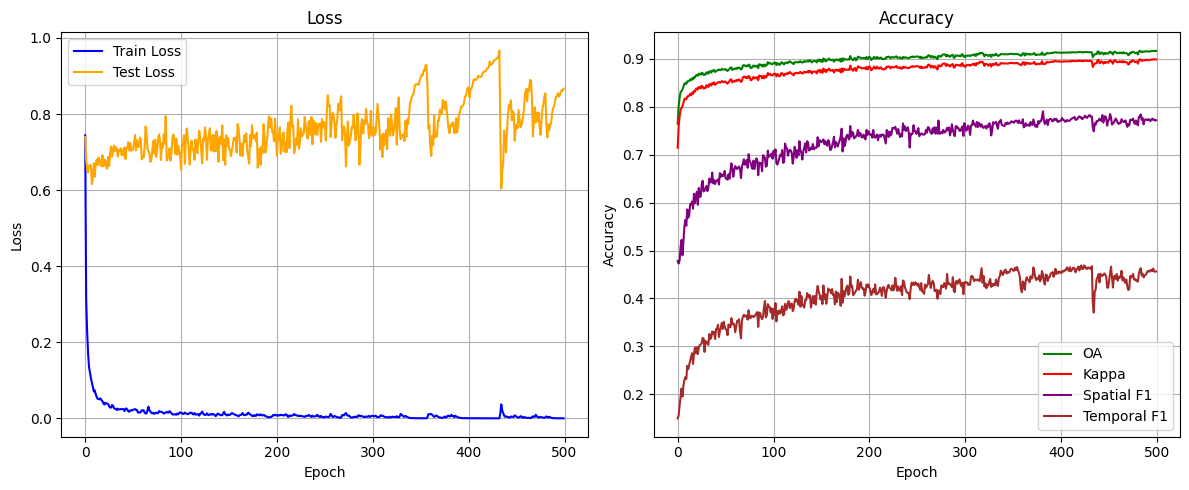

In [14]:
# 在训练结束后，绘制损失和精度变化曲线
plt.figure(figsize=(12, 5))

# 绘制训练损失
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss', color='blue')
plt.plot(test_loss_list, label='Test Loss', color='orange')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# 绘制分类精度
plt.subplot(1, 2, 2)
plt.plot(test_classification_OA, label='OA', color='green')
plt.plot(test_classification_Kappa, label='Kappa', color='red')
plt.plot(test_change_detection_spatial_f1, label='Spatial F1', color='purple')
plt.plot(test_change_detection_temporal_f1, label='Temporal F1', color='brown')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
# plt.savefig(r"H:\7.Eco_parameter\Hunan_LULC\Figures\loss_test_accuracy.png",dpi=600)
plt.show()

In [15]:
pred.shape, test_labels.shape

(torch.Size([856, 6, 34]), torch.Size([856, 34]))

最终的混淆矩阵：
         0        1        2        3        4        5
0  39269.0     51.0     37.0     11.0      3.0    143.0
1     61.0  43747.0    585.0      3.0    223.0    294.0
2    112.0   2703.0  27795.0     23.0     81.0    517.0
3    295.0    319.0   1093.0  23523.0   3843.0   2159.0
4   1079.0    910.0    169.0    694.0  48425.0   1462.0
5    568.0   1122.0    748.0    211.0    437.0  35285.0


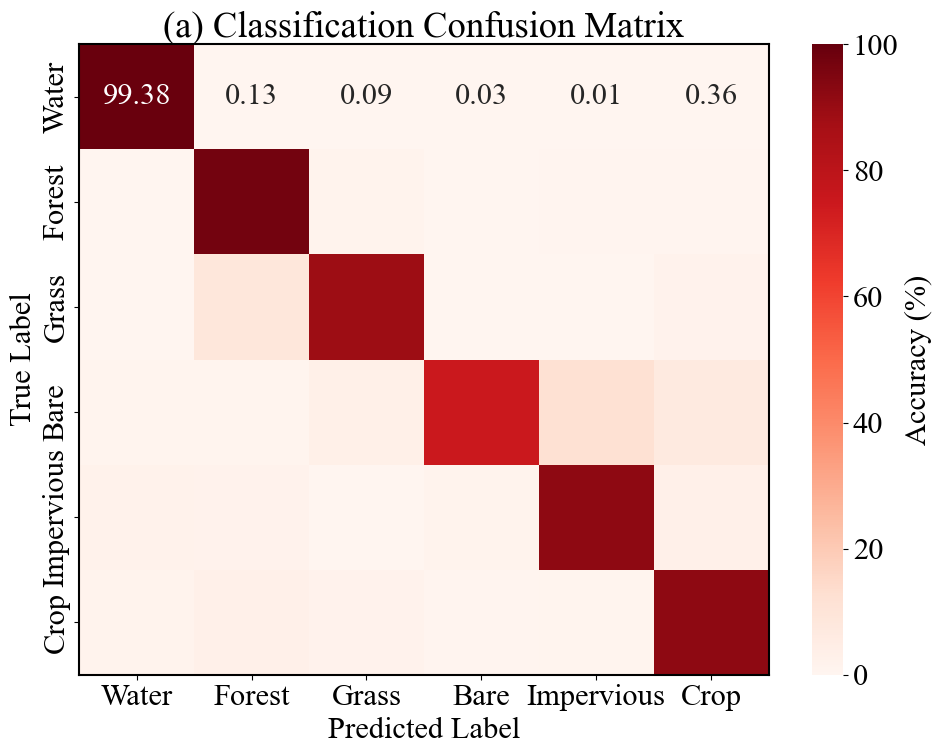

In [16]:
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 22
# 输出最终的混淆矩阵
confusion_matrix = evaluator.confusion_matrix
print("最终的混淆矩阵：")
print(pd.DataFrame(confusion_matrix))

# 将混淆矩阵归一化为百分比
normalized_confusion_matrix = confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis] * 100

# 定义类别名称
class_names = ['Water', 'Forest', 'Grass', 'Bare', 'Impervious', 'Crop']

# 绘制混淆矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(normalized_confusion_matrix, annot=True, fmt='.2f', cmap='Reds', vmin=0,vmax=100,
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Accuracy (%)'})
plt.title('(a) Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)  # 设置边框宽度
plt.tight_layout()
# plt.savefig(r"H:\7.Eco_parameter\Hunan_LULC\Figures\classification_confusion_matrix_500epoch.png",dpi=600)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_41780\2248652684.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  confusion_matrix_df = confusion_matrix_df.applymap(lambda x: "0" if x == 0 else f"{x:.2f}")


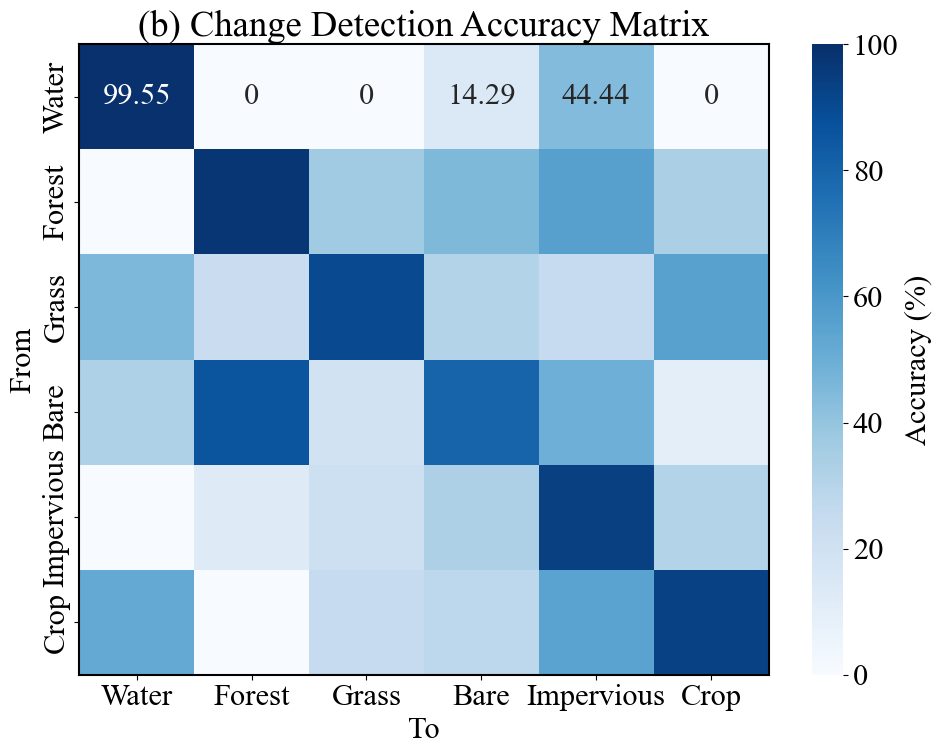

In [17]:
num_classes = 6
class_names = ["Water", "Forest", "Grass", "Bare", "Impervious", "Crop"]  # 示例类别名
tolerance = 3   # 容差范围为3年

# 初始化准确率矩阵和计数矩阵
confusion_matrix_accuracy = np.zeros((num_classes, num_classes))
confusion_matrix_count = np.zeros((num_classes, num_classes))

# 将 pred 转为预测类别
with torch.no_grad():
    for test_series, test_labels in test_dl:
        test_series, test_labels = test_series.to(DEVICE), test_labels.to(DEVICE)
        pred = model(test_series.float())  # [batch_size, num_classes, time_steps]
        pred = torch.argmax(pred, dim=1).cpu().numpy()  # 转为 [batch_size, time_steps] 的类别预测
        labels = test_labels.cpu().numpy()  # [batch_size, time_steps]

        # 遍历每个样本和每个时间段，统计转换情况
        for pre, label in zip(pred, labels):
            for t in range(1, pre.shape[0]):
                # 真实的 "From -> To" 转换
                true_from = int(label[t - 1])
                true_to = int(label[t])

                # 统计真实标签中的每种转换总数
                if (0 <= true_from < num_classes) and (0 <= true_to < num_classes):
                    confusion_matrix_count[true_from, true_to] += 1  # 累加真实转换的计数

                    # 容差范围内的预测检测
                    correct_detected = False
                    for delta in range(-tolerance, tolerance + 1):
                        if t + delta >= 1 and t + delta < pre.shape[0]:  # 检查边界
                            pred_from = int(pre[t + delta - 1])  # 容差范围内的起始点
                            pred_to = int(pre[t + delta])        # 容差范围内的结束点

                            # 检查容差范围内是否有匹配的转换
                            if pred_from == true_from and pred_to == true_to:
                                correct_detected = True
                                break

                    # 如果在容差范围内有正确预测，则记录为正确检测
                    if correct_detected:
                        confusion_matrix_accuracy[true_from, true_to] += 1

# 将出现次数少于 10 的转换设置为 0
confusion_matrix_accuracy[confusion_matrix_count < 10] = 0
confusion_matrix_count[confusion_matrix_count < 10] = 0

# 计算准确率矩阵：对于每种转换，将正确预测的次数除以真实标签中的转换总数
with np.errstate(divide='ignore', invalid='ignore'):  # 忽略除以零的警告
    confusion_matrix_accuracy = np.divide(confusion_matrix_accuracy, confusion_matrix_count) * 100

# 将 NaN 转换为 0 以在热图中显示
confusion_matrix_accuracy = np.nan_to_num(confusion_matrix_accuracy, nan=0)

# 将准确率矩阵转换为 DataFrame，并将 0 替换为 "0"
confusion_matrix_df = pd.DataFrame(confusion_matrix_accuracy, index=class_names, columns=class_names)
confusion_matrix_df = confusion_matrix_df.applymap(lambda x: "0" if x == 0 else f"{x:.2f}")

# 绘制准确率混淆矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_accuracy, annot=confusion_matrix_df, fmt="", cmap="Blues", vmin=0, vmax=100,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Accuracy (%)'})

# 设置轴标签
plt.xlabel("To")
plt.ylabel("From")
plt.title("(b) Change Detection Accuracy Matrix")
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)  # 设置边框宽度
plt.tight_layout()
# plt.title(f"Transition Accuracy Matrix (Tolerance ±{tolerance} years, Filtered for Counts >= 10)")
# plt.savefig(r"H:\7.Eco_parameter\Hunan_LULC\Figures\Change_detection_accuracy_matrix_500epoch.png",dpi=600)
plt.show()

In [18]:
# import os
# import numpy as np
# import torch
# from osgeo import gdal
# from torch.utils.data import DataLoader, Dataset

# # 定义数据集类
# class TimeSeriesDataset(Dataset):
#     def __init__(self, data_dir, mean, std):
#         self.data_dir = data_dir
#         self.mean = mean
#         self.std = std
#         self.files = sorted([f for f in os.listdir(data_dir) if f.endswith('.tif')])

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         file_path = os.path.join(self.data_dir, self.files[idx])
#         data = gdal.Open(file_path).ReadAsArray().astype(np.float32)
#         data = (data - self.mean[:, None, None]) / self.std[:, None, None]
#         return torch.tensor(data, dtype=torch.float32)

# # 加载模型
# model = UNet(in_channels=6, out_channels=6).to(DEVICE)
# model.load_state_dict(torch.load(r"H:\7.Eco_parameter\Hunan_LULC\Best_model\best_model_UNet.pth"))
# model.eval()

# # 预处理参数
# mean = mean
# std = std

# # 处理每个区域
# data_root = r"H:\7.Eco_parameter\Hunan_LULC\Split_zone"
# output_root = r"H:\7.Eco_parameter\Hunan_LULC\Output"

# for tile in os.listdir(data_root):
#     tile_dir = os.path.join(data_root, tile)
#     if os.path.isdir(tile_dir):  # 确保是目录
#         dataset = TimeSeriesDataset(tile_dir, mean, std)
#         dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

#         # 初始化一个空的时间序列张量
#         predictions = []

#         for data in dataloader:
#             data = data.to(DEVICE)  # 形状为 [1, 6, 4000, 4000]
#             with torch.no_grad():
#                 pred = model(data)
#                 pred = torch.argmax(pred, dim=1).cpu().numpy().squeeze()  # 形状为 [4000, 4000]
#                 predictions.append(pred)

#         # 将预测结果拼接成一个张量，形状为 [34, 4000, 4000]
#         predictions = np.stack(predictions, axis=0)

#         # 保存结果为一个包含34个波段的文件
#         output_file = os.path.join(output_root, f"{tile}_1990_2023.tif")
#         driver = gdal.GetDriverByName('GTiff')
#         out_ds = driver.Create(output_file, 4000, 4000, 34, gdal.GDT_Byte)
#         for year_idx in range(predictions.shape[0]):
#             out_ds.GetRasterBand(year_idx + 1).WriteArray(predictions[year_idx])
#         out_ds.FlushCache()
#         out_ds = None

# print("所有区域处理完成。")